# Évaluation quantitative du modèle Llama-3.2-1B fine-tuné (QLoRA) vs modèle de base

Ce notebook est la version interactive du script `evaluate_model.py`.
Il est conçu pour fonctionner sur **GPU** (recommandé avec Unsloth) ou sur **CPU** (fallback via HuggingFace classique).

Métriques calculées :
1. **Perplexity** sur le test set (fine-tuné vs base)
2. **ROUGE-1 / ROUGE-2 / ROUGE-L** (générations vs textes réels)
3. **BERTScore** (générations vs textes réels)
4. **Distinctiveness politique** : classification linéaire sur TF-IDF des textes générés


In [1]:
!pip install --upgrade pyarrow datasets
!pip install rouge-score bert-score scikit-learn seaborn tqdm pandas matplotlib python-dotenv huggingface_hub
!pip install unsloth unsloth_zoo -q

  Using cached datasets-4.8.5-py3-none-any.whl.metadata (19 kB)
Using cached datasets-4.8.5-py3-none-any.whl (528 kB)
  Attempting uninstall: datasets
    Found existing installation: datasets 4.3.0
    Uninstalling datasets-4.3.0:
      Successfully uninstalled datasets-4.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
unsloth 2026.4.8 requires datasets!=4.0.*,!=4.1.0,<4.4.0,>=3.4.1, but you have datasets 4.8.5 which is incompatible.
unsloth-zoo 2026.4.9 requires datasets!=4.0.*,!=4.1.0,<4.4.0,>=3.4.1, but you have datasets 4.8.5 which is incompatible.


## 1. Imports et Détection du matériel (CPU/GPU)

In [2]:
import json
import os
import re
from pathlib import Path
from collections import defaultdict

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm

# Détection du device (CPU ou GPU)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device détecté : {device}")

if device == "cpu":
    print("\nATTENTION : L'inférence sur CPU sera très lente pour la génération de texte.")
    print("Les optimisations Unsloth et la quantification 4-bit seront automatiquement désactivées.")


Device détecté : cuda


## 2. Configuration Globale

In [3]:
OUT_DIR = Path("eval_results")
OUT_DIR.mkdir(exist_ok=True)

PARTIES_ORDER = [
    "Extreme_Droite", "Droite", "Centre",
    "Socialiste", "Communiste_et_Extreme_Gauche",
    "Ecologiste", "Regionaliste",
]

# 8 profils tests (un par famille politique) - identiques à ceux du script d'origine
CANDIDATS_TEST = [
    {"famille": "Extreme_Droite",              "prenom": "Martial",      "nom": "Delaborde",
     "profession": "Artisan commerçant",        "soutien": "Front national",
     "departement": "Bouches-du-Rhône",         "date": "1988", "tour": "1"},
    {"famille": "Droite",                       "prenom": "Charles-Henri","nom": "de Courcelles",
     "profession": "Chef d'entreprise",         "soutien": "Rassemblement pour la République",
     "departement": "Hauts-de-Seine",           "date": "1988", "tour": "1"},
    {"famille": "Centre",                       "prenom": "François",     "nom": "Lemaire",
     "profession": "Médecin généraliste",       "soutien": "Union pour la démocratie française",
     "departement": "Calvados",                 "date": "1988", "tour": "1"},
    {"famille": "Socialiste",                   "prenom": "Alain",        "nom": "Mignot",
     "profession": "Professeur de lycée",       "soutien": "Parti socialiste",
     "departement": "Nord",                     "date": "1988", "tour": "1"},
    {"famille": "Communiste_et_Extreme_Gauche", "prenom": "Marcel",       "nom": "Roussillon",
     "profession": "Ouvrier métallurgiste",     "soutien": "Parti communiste français",
     "departement": "Seine-Saint-Denis",        "date": "1988", "tour": "1"},
    {"famille": "Ecologiste",                   "prenom": "Brigitte",     "nom": "Valette",
     "profession": "Chercheuse en biologie",    "soutien": "Verts",
     "departement": "Isère",                    "date": "1988", "tour": "1"},
    {"famille": "Regionaliste",                 "prenom": "Yannick",      "nom": "Le Goff",
     "profession": "Agriculteur",               "soutien": "Union démocratique bretonne",
     "departement": "Finistère",                "date": "1988", "tour": "1"},
]


## 3. Fonctions Utilitaires (Helpers)

In [4]:
def normalize_party(soutien) -> str:
    if pd.isna(soutien) or str(soutien) == "non mentionné":
        return "A_EXCLURE"
    s = str(soutien).lower().split(';')[0].strip()
    if any(x in s for x in ["front national","fn","extrême droite"]):
        return "Extreme_Droite"
    if any(x in s for x in ["communiste","pcf","lutte ouvrière","lcr","psu"]):
        return "Communiste_et_Extreme_Gauche"
    if any(x in s for x in ["écolog","ecolog","vert","biosphère"]) and "chasse" not in s:
        return "Ecologiste"
    if any(x in s for x in ["socialiste","ps","mrg","radicaux de gauche"]):
        return "Socialiste"
    if any(x in s for x in ["rpr","gaulliste","parti républicain","droite"]):
        return "Droite"
    if any(x in s for x in ["udf","centre","cds","parti radical"]):
        return "Centre"
    if any(x in s for x in ["corse","breton","catalan","indépendantiste"]):
        return "Regionaliste"
    if any(x in s for x in ["sans étiquette","indépendant"]):
        return "Sans_Etiquette"
    return "A_EXCLURE"

def build_prompt(row: dict, tokenizer) -> str:
    system_msg = (
        "Tu es un expert en rhétorique politique française et un archiviste spécialisé "
        "dans l'histoire de la Ve République. Ta tâche est de rédiger une profession de "
        "foi électorale historique et convaincante. Tu dois adopter le ton, le vocabulaire "
        "et le positionnement idéologique correspondant au parti politique du candidat, "
        "en respectant scrupuleusement le contexte historique de l'année de l'élection. "
        "Le texte généré doit être structuré, persuasif, et s'adresser directement aux "
        "électeurs du département ciblé. Ne rédige que le corps du texte."
    )
    user_msg = (
        "Rédige la profession de foi à partir des caractéristiques suivantes :\n"
        f"- Candidat : {row.get('prenom', '')} {row.get('nom', '')}\n"
        f"- Profession : {row.get('profession', '')}\n"
        f"- Soutien politique : {row.get('soutien', '')}\n"
        f"- Élection : Élections législatives, Tour {row.get('tour', '')}\n"
        f"- Date : {row.get('date', '')}\n"
        f"- Département : {row.get('departement', '')}"
    )
    messages = [
        {"role": "system", "content": system_msg},
        {"role": "user",   "content": user_msg},
    ]
    return tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )

def generate_texts_batch(model, tokenizer, prompts: list, max_new_tokens=512, device="cuda", batch_size=8) -> list:
    """Génère des textes par lots pour maximiser l'utilisation du GPU."""
    # Assurez-vous que le tokenizer sait de quel côté "remplir" (padding) pour la génération
    tokenizer.padding_side = "left" 
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    all_generated_texts = []
    
    # On découpe la liste complète des prompts en petits lots (batches)
    for i in range(0, len(prompts), batch_size):
        batch_prompts = prompts[i:i+batch_size]
        
        # On prépare le lot pour le modèle (padding=True est crucial ici)
        inputs = tokenizer(batch_prompts, return_tensors="pt", padding=True, truncation=True).to(device)
        
        with torch.no_grad():
            output_ids = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                temperature=0.6,
                top_p=0.9,
                repetition_penalty=1.2,
                do_sample=True,
                pad_token_id=tokenizer.eos_token_id,
            )
            
        # Pour chaque séquence du lot, on ne garde que la partie générée (après le prompt)
        for j in range(len(batch_prompts)):
            # On récupère la longueur du prompt initial spécifique à cet élément
            input_length = inputs["attention_mask"][j].sum().item() 
            generated = output_ids[j, input_length:]
            decoded_text = tokenizer.decode(generated, skip_special_tokens=True).strip()
            all_generated_texts.append(decoded_text)
            
    return all_generated_texts
    
    # On ne décode que les tokens générés
    generated = output_ids[0, inputs["input_ids"].shape[1]:]
    return tokenizer.decode(generated, skip_special_tokens=True).strip()


## 4. Fonctions d'Évaluation (Perplexité, ROUGE, BERTScore, Distinctivité)

In [5]:
def compute_perplexity(model, tokenizer, texts: list, device="cuda", max_length=1024, batch_size=4) -> float:
    model.eval()
    total_nll = 0.0
    total_tokens = 0
    for i in tqdm(range(0, len(texts), batch_size), desc="Perplexity"):
        batch_texts = texts[i:i+batch_size]
        enc = tokenizer(
            batch_texts, return_tensors="pt", padding=True, 
            truncation=True, max_length=max_length
        ).to(device)
        
        labels = enc["input_ids"].clone()
        labels[enc["attention_mask"] == 0] = -100  # Ignore padding
        
        with torch.no_grad():
            out = model(**enc, labels=labels)
            
        n_tokens = (labels != -100).sum().item()
        total_nll += out.loss.item() * n_tokens
        total_tokens += n_tokens

    mean_nll = total_nll / total_tokens if total_tokens > 0 else float("inf")
    return float(np.exp(mean_nll))

def compute_rouge(hypotheses: list, references: list) -> dict:
    try:
        from rouge_score import rouge_scorer
    except ImportError:
        print("⚠ rouge_score non installé. Utilisez `pip install rouge-score`")
        return {}

    scorer = rouge_scorer.RougeScorer(["rouge1","rouge2","rougeL"], use_stemmer=False)
    results = defaultdict(list)
    for hyp, ref in zip(hypotheses, references):
        scores = scorer.score(ref, hyp)
        for k, v in scores.items():
            results[k].append(v.fmeasure)
    return {k: float(np.mean(v)) for k, v in results.items()}

def compute_bertscore(hypotheses: list, references: list, lang="fr") -> dict:
    try:
        from bert_score import score as bert_score_fn
    except ImportError:
        print("⚠ bert_score non installé. Utilisez `pip install bert-score`")
        return {}

    P, R, F1 = bert_score_fn(hypotheses, references, lang=lang, verbose=False)
    return {
        "precision": float(P.mean()),
        "recall":    float(R.mean()),
        "f1":        float(F1.mean()),
        "f1_per_doc": F1.tolist(),
    }

def political_distinctiveness(generated_texts: list, generated_labels: list, real_texts: list, real_labels: list) -> dict:
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
    import seaborn as sns

    vec = TfidfVectorizer(max_features=5000, sublinear_tf=True, token_pattern=r"(?u)\b[a-zà-ÿ]{3,}\b")
    X_train = vec.fit_transform([t.lower() for t in real_texts])
    clf = LogisticRegression(max_iter=500, C=1.0, random_state=42)
    clf.fit(X_train, real_labels)

    X_gen = vec.transform([t.lower() for t in generated_texts])
    preds = clf.predict(X_gen)
    acc   = accuracy_score(generated_labels, preds)

    print(f"\n=== Distinctiveness politique ===")
    print(f"Accuracy (prédiction étiquette sur générations) : {acc:.3f}")
    print(classification_report(generated_labels, preds, zero_division=0))

    labels_unique = sorted(set(generated_labels))
    cm = confusion_matrix(generated_labels, preds, labels=labels_unique)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels_unique, yticklabels=labels_unique, ax=ax)
    ax.set_title("Matrice de confusion : familles politiques (générations)", fontsize=12)
    ax.set_xlabel("Prédit"); ax.set_ylabel("Réel")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "political_classifier_confusion.png", dpi=150)
    plt.show()

    return {"accuracy": acc, "predictions": preds.tolist()}


## 5. Fonctions de tracé graphique (Plots)

In [6]:
def plot_perplexity_comparison(ppl_base: float, ppl_finetuned: float):
    fig, ax = plt.subplots(figsize=(5, 4))
    models  = ["Llama-3.2-1B\n(base)", "Llama-3.2-1B\n(fine-tuné)"]
    values  = [ppl_base, ppl_finetuned]
    colors  = ["#999999", "#2196F3"]
    bars = ax.bar(models, values, color=colors, edgecolor="white", width=0.4)
    ax.bar_label(bars, fmt="%.2f", padding=4, fontsize=11, fontweight="bold")
    ax.set_title("Perplexité sur le test set Archelec", fontsize=12)
    ax.set_ylabel("Perplexité (↓ meilleure)")
    ax.set_ylim(0, max(values) * 1.25)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "perplexity_comparison.png", dpi=150)
    plt.show()

def plot_rouge_scores(rouge_base: dict, rouge_ft: dict):
    if not rouge_base or not rouge_ft:
        return
    metrics = list(rouge_base.keys())
    x = np.arange(len(metrics))
    w = 0.35
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(x - w/2, [rouge_base[m] for m in metrics], w, label="Base", color="#999", edgecolor="white")
    ax.bar(x + w/2, [rouge_ft[m]   for m in metrics], w, label="Fine-tuné", color="#2196F3", edgecolor="white")
    ax.set_xticks(x)
    ax.set_xticklabels([m.upper() for m in metrics])
    ax.set_ylabel("F1 score")
    ax.set_title("Scores ROUGE : base vs fine-tuné (test set)")
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR / "rouge_scores.png", dpi=150)
    plt.show()

def plot_bertscore_distribution(f1_base: list, f1_ft: list):
    if not f1_base or not f1_ft:
        return
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(f1_base, bins=30, alpha=0.6, label="Base", color="#999")
    ax.hist(f1_ft,   bins=30, alpha=0.6, label="Fine-tuné", color="#2196F3")
    ax.axvline(np.mean(f1_base), color="gray", lw=2, ls="--", label=f"Moy. base {np.mean(f1_base):.3f}")
    ax.axvline(np.mean(f1_ft),   color="#0D47A1", lw=2, ls="--", label=f"Moy. FT {np.mean(f1_ft):.3f}")
    ax.set_title("Distribution BERTScore F1 : base vs fine-tuné")
    ax.set_xlabel("BERTScore F1")
    ax.set_ylabel("Fréquence")
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR / "bertscore_distribution.png", dpi=150)
    plt.show()


## 6. Chargement des Modèles
Le code s'adapte automatiquement selon que vous utilisez un GPU ou un CPU.

In [7]:
import os
import getpass
from dotenv import load_dotenv
from huggingface_hub import login

# Tentative de chargement depuis le fichier .env
load_dotenv(override=True)
hf_token = os.getenv("HF_TOKEN")

# Si le fichier .env ne fonctionne pas, on demande le token explicitement
if not hf_token:
    print("Token introuvable dans le .env.")
    hf_token = getpass.getpass("Veuillez coller votre token Hugging Face (il sera masqué) : ")

# Connexion globale
login(token=hf_token)

model_id = "fdechamps/Llama-1B-Archelec-20260409-1742" # Vérifiez que ce nom est exact sur le Hub
base_id = "meta-llama/Llama-3.2-1B-Instruct"

# Variable device à définir si elle ne l'est pas plus haut dans votre script
device = "cuda" # ou autre logique de détection

print("Chargement des modèles...")

if device == "cuda":
    from unsloth import FastLanguageModel
    
    print("Configuration GPU détectée : Utilisation de Unsloth et quantification 4-bit.")
    
   # Modèle fine-tuné
    model_ft, tokenizer = FastLanguageModel.from_pretrained(
        model_name=model_id, 
        max_seq_length=2048, 
        dtype=None, 
        load_in_4bit=True,
        token=hf_token,
        disable_log_stats=True  # <-- Paramètre à ajouter
    )

    # Modèle de base
    model_base, _ = FastLanguageModel.from_pretrained(
        model_name=base_id, 
        max_seq_length=2048, 
        dtype=None, 
        load_in_4bit=True,
        token=hf_token,
        disable_log_stats=True  # <-- Paramètre à ajouter ici également
    )
    FastLanguageModel.for_inference(model_base)
    
else:
    print("Configuration CPU détectée : Fallback sur HuggingFace (PeftModel) classique.")
    from transformers import AutoModelForCausalLM, AutoTokenizer
    from peft import PeftModel
    import torch
    
    tokenizer = AutoTokenizer.from_pretrained(base_id, token=hf_token)
    
    print("Chargement du modèle de base en mémoire...")
    model_base = AutoModelForCausalLM.from_pretrained(
        base_id, 
        device_map="cpu", 
        torch_dtype=torch.float32,
        token=hf_token
    )
    
    print("Application des poids LoRA...")
    try:
        # Passage du token également requis pour PeftModel si l'adapter est privé
        model_ft = PeftModel.from_pretrained(
            model_base, 
            model_id,
            token=hf_token
        )
    except Exception as e:
        print(f"Erreur au chargement des poids LoRA : {e}")
        model_ft = model_base  # Fallback final en cas d'erreur

Token introuvable dans le .env.


/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Chargement des modèles...
🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
Configuration GPU détectée : Utilisation de Unsloth et quantification 4-bit.
==((====))==  Unsloth 2026.4.8: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A2. Num GPUs = 1. Max memory: 14.612 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.6. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights: 100%|██████████| 146/146 [00:00<00:00, 272.37it/s]
Unsloth: Will load unsloth/llama-3.2-1b-instruct-unsloth-bnb-4bit as a legacy tokenizer.
Unsloth 2026.4.8 patched 16 layers with 16 QKV layers, 16 O layers and 16 MLP layers.


==((====))==  Unsloth 2026.4.8: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A2. Num GPUs = 1. Max memory: 14.612 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.6. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights: 100%|██████████| 146/146 [00:00<00:00, 260.21it/s]
Unsloth: Will load unsloth/llama-3.2-1b-instruct-unsloth-bnb-4bit as a legacy tokenizer.


## 7. Chargement des données de test

In [8]:
from datasets import load_dataset
import glob
from pathlib import Path
import pandas as pd

# Sur Onyxia, les données sont déjà extraites dans le répertoire local.
data_dir = "data"
n_test = 100

PATTERNS = [
    f"{data_dir}/1981/legislatives/*PF*.txt",
    f"{data_dir}/1988/legislatives/*PF*.txt",
    f"{data_dir}/1993/legislatives/*PF*.txt",
]

files = [Path(f) for pat in PATTERNS for f in sorted(glob.glob(pat))]
print("Chargement du dataset...")

files_str = [str(f) for f in files]
if not files_str:
    raise ValueError(f"Aucun fichier trouvé. Vérifiez que le dossier '{data_dir}' se trouve bien dans le même répertoire que ce notebook.")

dataset = load_dataset("text", data_files=files_str, split="train", sample_by="document")
meta = pd.read_csv(f"{data_dir}/archelect_search.csv")

COLS = ["id","titulaire-prenom","titulaire-nom","titulaire-profession",
        "titulaire-soutien","contexte-tour","date","departement-nom"]
meta_dict = meta[[c for c in COLS if c in meta.columns]].set_index("id").to_dict("index")

def add_meta(ex, idx):
    p = files[idx]
    ex["id"] = p.stem
    m = meta_dict.get(p.stem, {})
    for k, col in [("prenom","titulaire-prenom"),("nom","titulaire-nom"),
                    ("profession","titulaire-profession"),("soutien","titulaire-soutien"),
                    ("tour","contexte-tour"),("date","date"),("departement","departement-nom")]:
        ex[k] = m.get(col, "non mentionné")
    return ex

dataset = dataset.map(add_meta, with_indices=True)
df = dataset.to_pandas()
df["famille"] = df["soutien"].apply(normalize_party)
df = df[df["famille"] != "A_EXCLURE"]

test_df = df.sample(frac=0.1, random_state=42).head(n_test)
print(f"\n{len(test_df)} documents dans le test set d'évaluation.")

Chargement du dataset...

100 documents dans le test set d'évaluation.


## 8. Lancement des Évaluations


=== A. Perplexité ===


Perplexity: 100%|██████████| 13/13 [00:49<00:00,  3.84s/it]

  Perplexité base     : 18.24
  Perplexité fine-tuné: 4.66


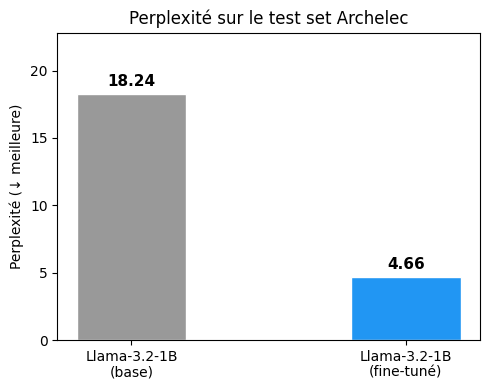


=== B. ROUGE & BERTScore ===
Préparation des 100 prompts...
Génération par lots (Batch Size: 8) sur le modèle Fine-Tuné...


Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_

Génération par lots (Batch Size: 8) sur le modèle de Base...


Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_

  ROUGE fine-tuné : {'rouge1': 0.32962109830830477, 'rouge2': 0.08687831191450826, 'rougeL': 0.14309711600375588}
  ROUGE base      : {'rouge1': 0.24090977929855936, 'rouge2': 0.040496111596048115, 'rougeL': 0.10354253808637569}


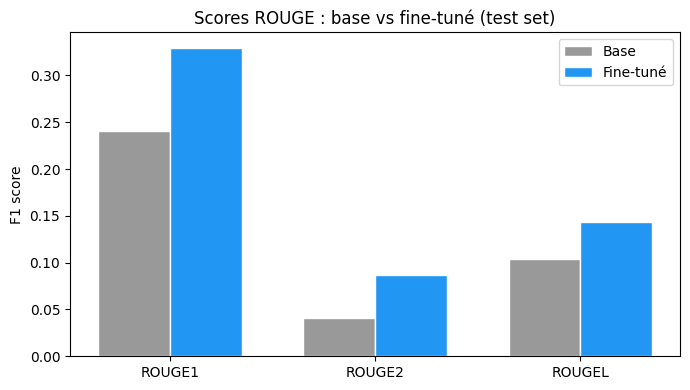

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4737.74it/s]
BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4678.75it/s]
BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------

  BERTScore F1 fine-tuné : 0.709
  BERTScore F1 base      : 0.632


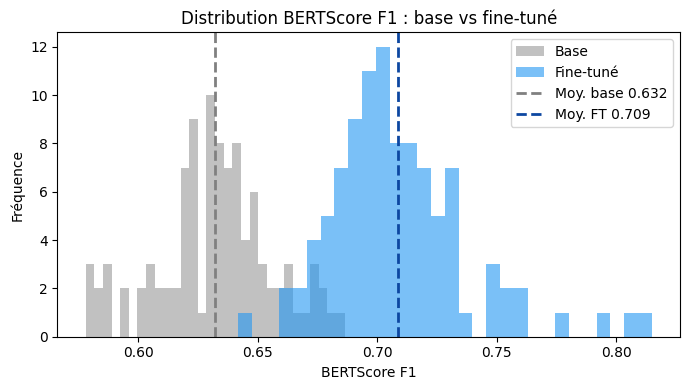

Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



=== C. Distinctivité politique ===
Génération par lots (Batch Size: 8) pour la distinctivité...


Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



=== Distinctiveness politique ===
Accuracy (prédiction étiquette sur générations) : 0.143
                              precision    recall  f1-score   support

                      Centre       0.00      0.00      0.00         3
Communiste_et_Extreme_Gauche       0.17      1.00      0.29         3
                      Droite       0.00      0.00      0.00         3
                  Ecologiste       0.00      0.00      0.00         3
              Extreme_Droite       0.00      0.00      0.00         3
                Regionaliste       0.00      0.00      0.00         3
                  Socialiste       0.00      0.00      0.00         3

                    accuracy                           0.14        21
                   macro avg       0.02      0.14      0.04        21
                weighted avg       0.02      0.14      0.04        21



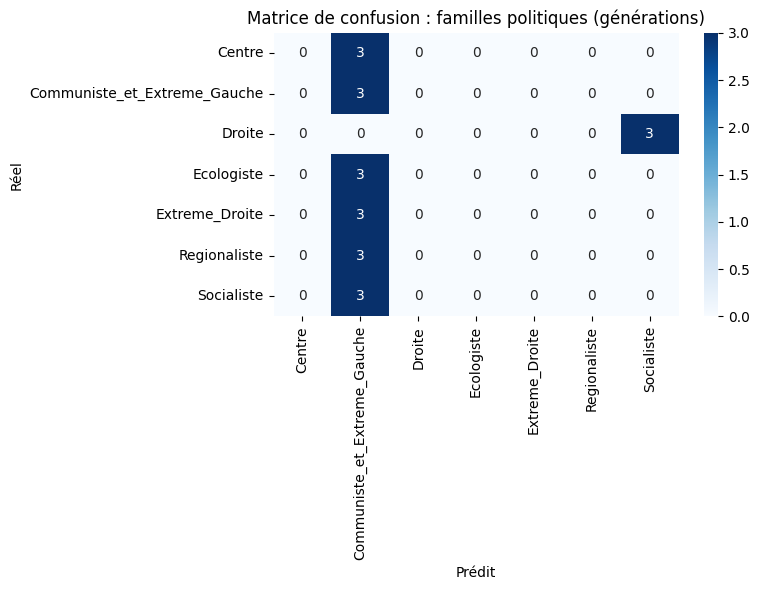


=== D. Sauvegarde des résultats ===

✓ Résultats sauvegardés dans eval_results/eval_summary.json


In [9]:
import warnings
import json
import torch # Ajouté au cas où

# Filtre les avertissements
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

max_gen = 512
# Définissez la taille du lot (batch_size) en fonction de la VRAM de votre GPU.
# Pour une T4 (16Go) avec Llama-1B 4-bit, un batch de 8 ou 16 devrait passer facilement.
BATCH_SIZE = 8 

# --- A. PERPLEXITÉ ---
print("\n=== A. Perplexité ===")
test_texts = test_df["text"].tolist()
ppl_ft   = compute_perplexity(model_ft,   tokenizer, test_texts, device, batch_size=BATCH_SIZE)
ppl_base = compute_perplexity(model_base, tokenizer, test_texts, device, batch_size=BATCH_SIZE)

print(f"  Perplexité base     : {ppl_base:.2f}")
print(f"  Perplexité fine-tuné: {ppl_ft:.2f}")
plot_perplexity_comparison(ppl_base, ppl_ft)

# --- B. ROUGE & BERTSCORE ---
print("\n=== B. ROUGE & BERTScore ===")
print(f"Préparation des {len(test_df)} prompts...")
references = test_df["text"].tolist()
all_prompts = [build_prompt(row.to_dict(), tokenizer) for _, row in test_df.iterrows()]

print(f"Génération par lots (Batch Size: {BATCH_SIZE}) sur le modèle Fine-Tuné...")
hypotheses_ft = generate_texts_batch(model_ft, tokenizer, all_prompts, max_gen, device, batch_size=BATCH_SIZE)

print(f"Génération par lots (Batch Size: {BATCH_SIZE}) sur le modèle de Base...")
hypotheses_base = generate_texts_batch(model_base, tokenizer, all_prompts, max_gen, device, batch_size=BATCH_SIZE)

rouge_ft   = compute_rouge(hypotheses_ft,   references)
rouge_base = compute_rouge(hypotheses_base, references)
print(f"  ROUGE fine-tuné : {rouge_ft}")
print(f"  ROUGE base      : {rouge_base}")
plot_rouge_scores(rouge_base, rouge_ft)

bs_ft   = compute_bertscore(hypotheses_ft,   references)
bs_base = compute_bertscore(hypotheses_base, references)
print(f"  BERTScore F1 fine-tuné : {bs_ft.get('f1', 'N/A'):.3f}")
print(f"  BERTScore F1 base      : {bs_base.get('f1', 'N/A'):.3f}")
plot_bertscore_distribution(bs_base.get("f1_per_doc",[]), bs_ft.get("f1_per_doc",[]))


# --- C. DISTINCTIVITÉ POLITIQUE ---
print("\n=== C. Distinctivité politique ===")
# On prépare la liste complète des candidats et des prompts
candidats_a_generer = CANDIDATS_TEST * 3
prompts_distinctivite = [build_prompt(c, tokenizer) for c in candidats_a_generer]
gen_labels = [c["famille"] for c in candidats_a_generer]

print(f"Génération par lots (Batch Size: {BATCH_SIZE}) pour la distinctivité...")
gen_texts = generate_texts_batch(model_ft, tokenizer, prompts_distinctivite, max_gen, device, batch_size=BATCH_SIZE)

distinctiveness = political_distinctiveness(
    gen_texts, gen_labels,
    test_df["text"].tolist(), test_df["famille"].tolist()
)

# --- D. SAUVEGARDE JSON ---
print("\n=== D. Sauvegarde des résultats ===")
summary = {
    "perplexity_base":       ppl_base,
    "perplexity_finetuned":  ppl_ft,
    "rouge_base":            rouge_base,
    "rouge_finetuned":       rouge_ft,
    "bertscore_base":        {k: v for k, v in bs_base.items() if k != "f1_per_doc"},
    "bertscore_finetuned":   {k: v for k, v in bs_ft.items()   if k != "f1_per_doc"},
    "political_accuracy":    distinctiveness.get("accuracy"),
}
(OUT_DIR / "eval_summary.json").write_text(
    json.dumps(summary, indent=2, ensure_ascii=False), encoding="utf-8"
)
print(f"\n✓ Résultats sauvegardés dans {OUT_DIR}/eval_summary.json")
# print(json.dumps(summary, indent=2, ensure_ascii=False)) # Optionnel pour réduire l'affichage

In [10]:
# --- INSTALLATION DES DÉPENDANCES NLP ---
!pip install spacy textstat sentence-transformers textblob -q
!python -m spacy download fr_core_news_sm -q

✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_sm')


In [11]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import spacy
import textstat

# Filtres et configuration
warnings.filterwarnings("ignore")
textstat.set_lang("fr")
nlp = spacy.load("fr_core_news_sm")

# Préparation d'un DataFrame comparatif
eval_df = pd.DataFrame({
    "famille": test_df["famille"].tolist(),
    "texte_reel": references,
    "texte_genere": hypotheses_ft
})

print("✅ Données préparées pour l'analyse NLP avancée.")

✅ Données préparées pour l'analyse NLP avancée.


In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

print("=== 1. Analyse TF-IDF (Langue de bois) ===")

# Liste de stopwords français personnalisée basique
stop_words_fr = ["le", "la", "les", "de", "des", "un", "une", "et", "à", "en", "pour", "dans", "que", "qui", "est", "sur", "pas", "plus", "nous", "vous", "ils", "elles", "je", "il", "ce", "cette", "avec", "par", "ne", "au", "aux", "du", "qu", "a", "ont", "sont", "être", "avoir"]

def get_top_tfidf_words(texts, top_n=10):
    vec = TfidfVectorizer(max_features=1000, stop_words=stop_words_fr, token_pattern=r"(?u)\b[a-zà-ÿ]{4,}\b")
    try:
        X = vec.fit_transform(texts)
        scores = X.sum(axis=0).A1
        words = vec.get_feature_names_out()
        return [words[i] for i in np.argsort(scores)[::-1][:top_n]]
    except ValueError: # Si la catégorie est vide ou trop petite
        return []

familles = eval_df["famille"].unique()
tfidf_results = []

for f in tqdm(familles, desc="Calcul TF-IDF par famille"):
    textes_reels = eval_df[eval_df["famille"] == f]["texte_reel"].str.lower()
    textes_gen = eval_df[eval_df["famille"] == f]["texte_genere"].str.lower()
    
    top_reels = get_top_tfidf_words(textes_reels)
    top_gen = get_top_tfidf_words(textes_gen)
    
    tfidf_results.append({
        "Famille": f,
        "Mots Réels": ", ".join(top_reels),
        "Mots Générés": ", ".join(top_gen)
    })

tfidf_df = pd.DataFrame(tfidf_results)
tfidf_df.to_csv(OUT_DIR / "tfidf_langue_de_bois.csv", index=False)
print("✓ Top mots TF-IDF sauvegardés dans tfidf_langue_de_bois.csv")
display(tfidf_df.head(3)) # Affiche un aperçu

=== 1. Analyse TF-IDF (Langue de bois) ===


Calcul TF-IDF par famille: 100%|██████████| 6/6 [00:00<00:00, 66.32it/s]

✓ Top mots TF-IDF sauvegardés dans tfidf_langue_de_bois.csv


,Famille,Mots Réels,Mots Générés
0,Extreme_Droite,"national, français, front, vote, nationale, fr...","national, front, nationale, voulez, français, ..."
1,Socialiste,"majorité, france, notre, gauche, ensemble, ell...","jean, circonscription, maire, suppléant, major..."
2,Centre,"jacques, clostermann, leur, seine, union, cand...","notre, suppléant, conseiller, union, saint, je..."



=== 2. Similarité Sémantique (Embeddings) ===


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4385.64it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Calcul Similarité Cosinus: 100%|██████████| 100/100 [00:02<00:00, 43.99it/s]


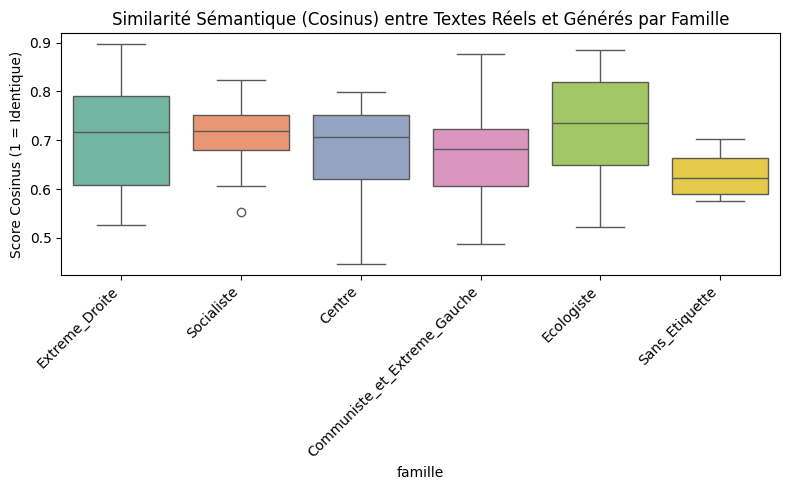

Similarité Cosinus Moyenne Globale : 0.701


In [13]:
from sentence_transformers import SentenceTransformer, util
import torch

print("\n=== 2. Similarité Sémantique (Embeddings) ===")
# Chargement d'un modèle léger et rapide
embedder = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2', device=device)

similarities = []
for idx, row in tqdm(eval_df.iterrows(), total=len(eval_df), desc="Calcul Similarité Cosinus"):
    emb_reel = embedder.encode(row["texte_reel"], convert_to_tensor=True)
    emb_gen = embedder.encode(row["texte_genere"], convert_to_tensor=True)
    # Cosinus entre le texte réel et sa propre génération
    sim = util.pytorch_cos_sim(emb_reel, emb_gen).item()
    similarities.append(sim)

eval_df["cos_sim"] = similarities

plt.figure(figsize=(8, 5))
sns.boxplot(data=eval_df, x="famille", y="cos_sim", palette="Set2")
plt.title("Similarité Sémantique (Cosinus) entre Textes Réels et Générés par Famille")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Score Cosinus (1 = Identique)")
plt.tight_layout()
plt.savefig(OUT_DIR / "semantic_similarity_boxplot.png", dpi=150)
plt.show()

print(f"Similarité Cosinus Moyenne Globale : {np.mean(similarities):.3f}")


=== 3. Complexité Lexicale et Lisibilité ===


Calcul TTR/Flesch (Générés): 100%|██████████| 100/100 [00:00<00:00, 17965.84it/s]


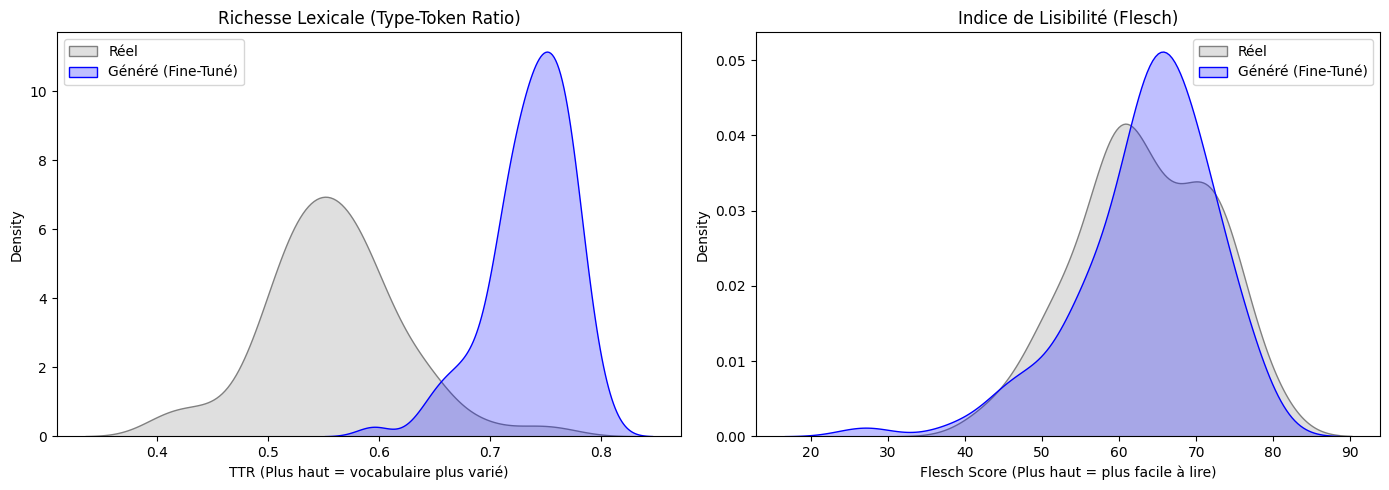

In [14]:
print("\n=== 3. Complexité Lexicale et Lisibilité ===")

def calculate_ttr(text):
    words = text.lower().split()
    if len(words) == 0: return 0
    return len(set(words)) / len(words)

tqdm.pandas(desc="Calcul TTR/Flesch (Réels)")
eval_df["TTR_reel"] = eval_df["texte_reel"].progress_apply(calculate_ttr)
eval_df["Flesch_reel"] = eval_df["texte_reel"].apply(textstat.flesch_reading_ease)

tqdm.pandas(desc="Calcul TTR/Flesch (Générés)")
eval_df["TTR_gen"] = eval_df["texte_genere"].progress_apply(calculate_ttr)
eval_df["Flesch_gen"] = eval_df["texte_genere"].apply(textstat.flesch_reading_ease)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Richesse Lexicale
sns.kdeplot(eval_df["TTR_reel"], fill=True, label="Réel", ax=axes[0], color="grey")
sns.kdeplot(eval_df["TTR_gen"], fill=True, label="Généré (Fine-Tuné)", ax=axes[0], color="blue")
axes[0].set_title("Richesse Lexicale (Type-Token Ratio)")
axes[0].set_xlabel("TTR (Plus haut = vocabulaire plus varié)")
axes[0].legend()

# Plot Lisibilité
sns.kdeplot(eval_df["Flesch_reel"], fill=True, label="Réel", ax=axes[1], color="grey")
sns.kdeplot(eval_df["Flesch_gen"], fill=True, label="Généré (Fine-Tuné)", ax=axes[1], color="blue")
axes[1].set_title("Indice de Lisibilité (Flesch)")
axes[1].set_xlabel("Flesch Score (Plus haut = plus facile à lire)")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUT_DIR / "lexical_complexity.png", dpi=150)
plt.show()


=== 4. Analyse des Entités Nommées (NER) ===


NER Textes Générés: 100%|██████████| 100/100 [00:04<00:00, 22.43it/s]


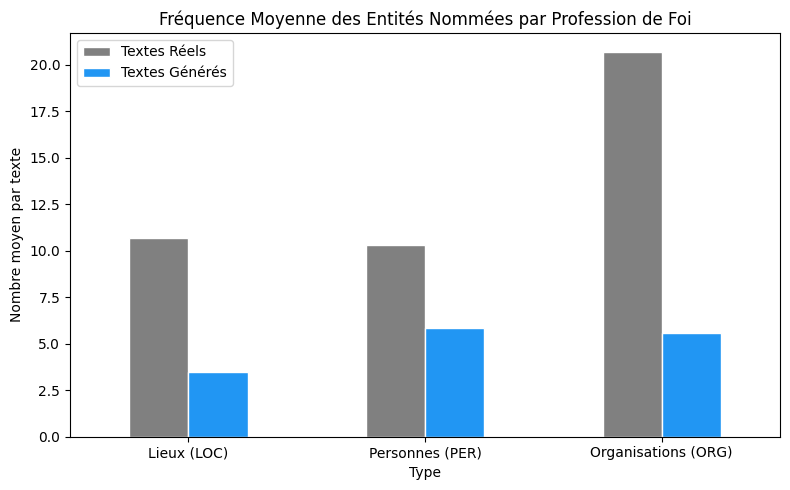

In [15]:
print("\n=== 4. Analyse des Entités Nommées (NER) ===")

def count_entities(text):
    doc = nlp(text)
    counts = {"LOC": 0, "PER": 0, "ORG": 0}
    for ent in doc.ents:
        if ent.label_ in counts:
            counts[ent.label_] += 1
    return counts

# Application du modèle NER
ent_reels = [count_entities(t) for t in tqdm(eval_df["texte_reel"], desc="NER Textes Réels")]
ent_gen = [count_entities(t) for t in tqdm(eval_df["texte_genere"], desc="NER Textes Générés")]

# Agrégation des résultats
ner_summary = pd.DataFrame({
    "Type": ["Lieux (LOC)", "Personnes (PER)", "Organisations (ORG)"],
    "Moyenne Réels": [np.mean([d["LOC"] for d in ent_reels]), np.mean([d["PER"] for d in ent_reels]), np.mean([d["ORG"] for d in ent_reels])],
    "Moyenne Générés": [np.mean([d["LOC"] for d in ent_gen]), np.mean([d["PER"] for d in ent_gen]), np.mean([d["ORG"] for d in ent_gen])]
}).set_index("Type")

ner_summary.plot(kind="bar", figsize=(8, 5), color=["grey", "#2196F3"], edgecolor="white")
plt.title("Fréquence Moyenne des Entités Nommées par Profession de Foi")
plt.ylabel("Nombre moyen par texte")
plt.xticks(rotation=0)
plt.legend(["Textes Réels", "Textes Générés"])
plt.tight_layout()
plt.savefig(OUT_DIR / "ner_comparison.png", dpi=150)
plt.show()


=== 5. Analyse de Sentiment (DistilCamemBERT) ===


Loading weights: 100%|██████████| 105/105 [00:00<00:00, 3781.41it/s]
CamembertForSequenceClassification LOAD REPORT from: cmarkea/distilcamembert-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Analyse des textes réels...
Analyse des textes générés...


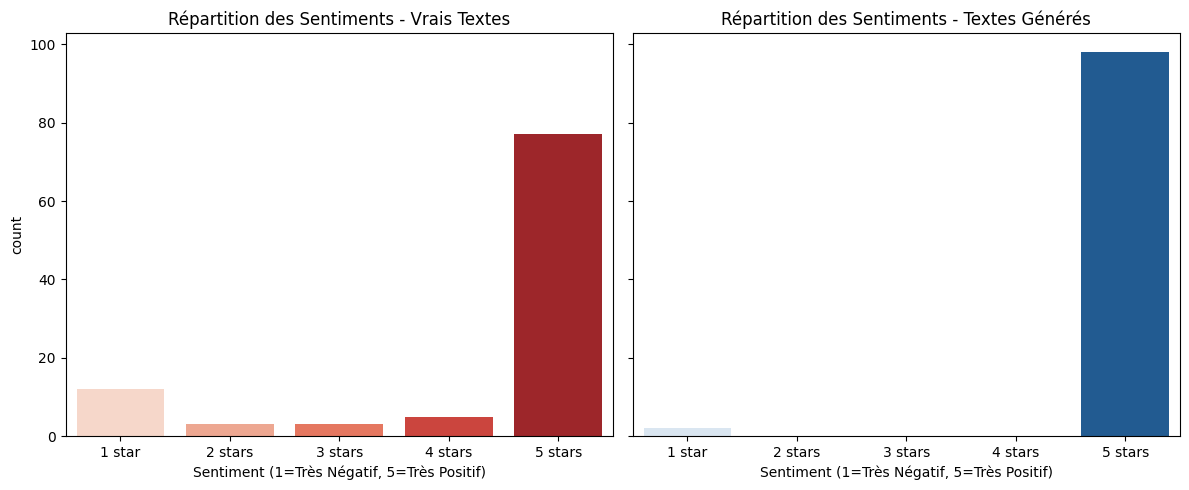

✓ Tableau complet des analyses sauvegardé dans nlp_analysis_results.csv


In [16]:
from transformers import pipeline

print("\n=== 5. Analyse de Sentiment (DistilCamemBERT) ===")
# Chargement du pipeline d'analyse de sentiment (modèle léger pour le français)
# Device=0 si GPU, -1 si CPU
device_id = 0 if str(device) == "cuda" else -1
sentiment_analyzer = pipeline(
    "sentiment-analysis", 
    model="cmarkea/distilcamembert-base-sentiment", 
    device=device_id,
    truncation=True, max_length=512
)

# Analyse des sentiments
def get_sentiment(texts):
    results = sentiment_analyzer(texts.tolist())
    return [res["label"] for res in results]

print("Analyse des textes réels...")
eval_df["sentiment_reel"] = get_sentiment(eval_df["texte_reel"])
print("Analyse des textes générés...")
eval_df["sentiment_gen"] = get_sentiment(eval_df["texte_genere"])

# Création du graphique croisé
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
sns.countplot(data=eval_df, x="sentiment_reel", order=["1 star", "2 stars", "3 stars", "4 stars", "5 stars"], ax=axes[0], palette="Reds")
axes[0].set_title("Répartition des Sentiments - Vrais Textes")
axes[0].set_xlabel("Sentiment (1=Très Négatif, 5=Très Positif)")

sns.countplot(data=eval_df, x="sentiment_gen", order=["1 star", "2 stars", "3 stars", "4 stars", "5 stars"], ax=axes[1], palette="Blues")
axes[1].set_title("Répartition des Sentiments - Textes Générés")
axes[1].set_xlabel("Sentiment (1=Très Négatif, 5=Très Positif)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig(OUT_DIR / "sentiment_comparison.png", dpi=150)
plt.show()

# Sauvegarde globale
eval_df.to_csv(OUT_DIR / "nlp_analysis_results.csv", index=False)
print("✓ Tableau complet des analyses sauvegardé dans nlp_analysis_results.csv")